# Flowsheet Visualization

This notebook demonstrates the interactive visualization capabilities in difflow.

**Key feature:** The visualization is generated directly from your flowsheet code, so the graph always reflects the actual computed process.

In [1]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from difflow import (
    Flowsheet, Unit,
    make_stream, get_flows,
    CSTR, CSTRParams,
    Flash, FlashParams,
    Mixer,
    render_flowsheet,
)

## 1. Build and Solve a Flowsheet

First, let's create a simple CSTR-Flash process using the standard difflow API.

In [2]:
# Define species
species = ["A", "B", "C"]

# Create flowsheet
fs = Flowsheet(species_order=species)

# Add feed stream
feed = make_stream(
    {"A": 100.0, "B": 0.0, "C": 0.0},
    T=350.0,
    P=101325.0
)
fs.add_feed("feed", feed)

# Define CSTR: A -> B (first order)
def rate_fn(C, T, params):
    k = params["k"] * jnp.exp(-params["Ea"] / (8.314 * T))
    return jnp.array([k * C["A"]])  # Return array for single reaction

# Stoichiometry matrix: rows=species (A,B,C), cols=reactions (1 reaction)
# A -> B means: A decreases by 1, B increases by 1, C unchanged
stoich = jnp.array([
    [-1.0],  # A: consumed
    [+1.0],  # B: produced
    [0.0],   # C: inert
])

cstr_params = CSTRParams(
    V=jnp.array(10.0),
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={"k": jnp.array(1e6), "Ea": jnp.array(50000.0)},
    species_order=species,
)
cstr = CSTR(cstr_params)

# Add reactor unit
fs.add_unit(Unit(
    name="reactor",
    operation=cstr,
    inlet_names=["feed"],
    outlet_names=["reactor_out"],
))

# Add a simple separator (pass-through for demo)
def simple_split(inlet):
    """Split stream 70/30."""
    product = {k: v * 0.7 if k.startswith("F_") else v for k, v in inlet.items()}
    waste = {k: v * 0.3 if k.startswith("F_") else v for k, v in inlet.items()}
    return product, waste

fs.add_unit(Unit(
    name="separator",
    operation=simple_split,
    inlet_names=["reactor_out"],
    outlet_names=["product", "waste"],
))

print(f"Flowsheet has {len(fs.units)} units")

Flowsheet has 2 units


In [3]:
# Solve the flowsheet
streams = fs.solve()

print("Solved stream compositions:")
for name, stream in streams.items():
    flows = get_flows(stream)
    total = sum(float(f) for f in flows.values())
    print(f"  {name}: total={total:.1f}")

Solved stream compositions:
  feed: total=100.0
  reactor_out: total=100.0
  product: total=70.0
  waste: total=30.0


## 2. Visualize the Flowsheet

Now visualize the flowsheet using `fs.to_graph()` or `fs.visualize()`. The graph is automatically generated from the flowsheet topology.

In [4]:
# Method 1: Use the visualize() convenience method
fig = fs.visualize(streams, title="CSTR-Separator Process")
fig

In [5]:
# Method 2: Get the graph object for more control
graph = fs.to_graph(streams, name="My Process")

print(f"Graph has {len(graph.nodes)} nodes and {len(graph.edges)} edges")
print("\nNodes:")
for node_id, node in graph.nodes.items():
    print(f"  {node_id}: {node.name} ({node.unit_type})")

print("\nEdges:")
for edge_id, edge in graph.edges.items():
    has_data = "with data" if edge.stream_data else "no data"
    print(f"  {edge_id}: {edge.source} -> {edge.target} ({has_data})")

Graph has 5 nodes and 4 edges

Nodes:
  _feed_feed: feed (feed)
  reactor: reactor (CSTR)
  separator: separator (simple_split)
  _product_product: product (product)
  _product_waste: waste (product)

Edges:
  feed: _feed_feed -> reactor (with data)
  reactor_out: reactor -> separator (with data)
  product: separator -> _product_product (with data)
  waste: separator -> _product_waste (with data)


## 3. Interactive Features

The visualization is fully interactive:

- **Zoom**: Scroll or pinch to zoom in/out
- **Pan**: Drag to move around
- **Tooltips**: Hover over nodes to see unit parameters, hover over edges to see stream data
- **Toolbar**: Use the toolbar on the right for reset, download, etc.

In [6]:
# Render with more options
fig = render_flowsheet(
    graph,
    title="Interactive Flowsheet",
    width=900,
    height=500,
    show_stream_labels=True,
    edge_width_scale=2.0,  # Scale edge width by flow rate
)
fig

## 4. Export to HTML

Export the visualization to a standalone HTML file for sharing.

In [7]:
from difflow.visualization.render import to_html

# Export to HTML
html = to_html(graph, filename="flowsheet.html")
print(f"Exported to flowsheet.html ({len(html)//1024} KB)")

Exported to flowsheet.html (4736 KB)


## 5. Manual Graph Construction (Optional)

You can also build graphs manually if needed, e.g., for diagrams that don't correspond to executable code.

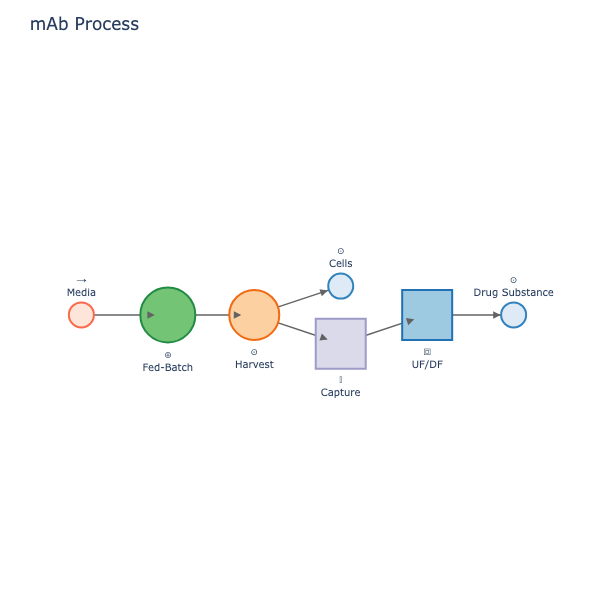

In [8]:
from difflow.visualization import FlowsheetGraph

# Manual graph for a bio process diagram
bio_graph = FlowsheetGraph(name="mAb Process")

# Add units
bio_graph.add_node("bioreactor", "Fed-Batch", unit_type="FedBatchBioreactor")
bio_graph.add_node("centrifuge", "Harvest", unit_type="DiscStackCentrifuge")
bio_graph.add_node("proa", "Capture", unit_type="ProteinAChromatography")
bio_graph.add_node("ufdf", "UF/DF", unit_type="TFF")

# Add connections
bio_graph.add_feed("bioreactor", "Media")
bio_graph.add_edge("bioreactor", "centrifuge", edge_id="Harvest")
bio_graph.add_edge("centrifuge", "proa", edge_id="Clarified")
bio_graph.add_edge("proa", "ufdf", edge_id="Eluate")
bio_graph.add_product("ufdf", "Drug Substance")
bio_graph.add_product("centrifuge", "Cells", source_port="cells")

fig = render_flowsheet(bio_graph, title="mAb Process")
fig

## Summary

The visualization module integrates directly with difflow:

```python
# Build flowsheet
fs = Flowsheet(species)
fs.add_feed("feed", feed_stream)
fs.add_unit(Unit("reactor", cstr, ["feed"], ["product"]))

# Solve
streams = fs.solve()

# Visualize - graph is generated from your code!
fs.visualize(streams)
```

The graph reflects exactly what you computed, with stream data shown in tooltips.